In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}

# Bigram Model

The Bigram model only takes the previous character to predict the next character. 

## Counts Approach

We create a frequency array $N$, where $N[i, j]$ contains the number of times the bigram $(i, j)$ appears in the dataset.

We normalize each row to create a distribution $P[i]$, which represents the distribution of characters that follow after $i$. Then to predict the next character after $i$, we sample from this distribution. 

In [4]:
N = torch.zeros((27, 27), dtype=torch.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(-0.5, 26.5, 26.5, -0.5)

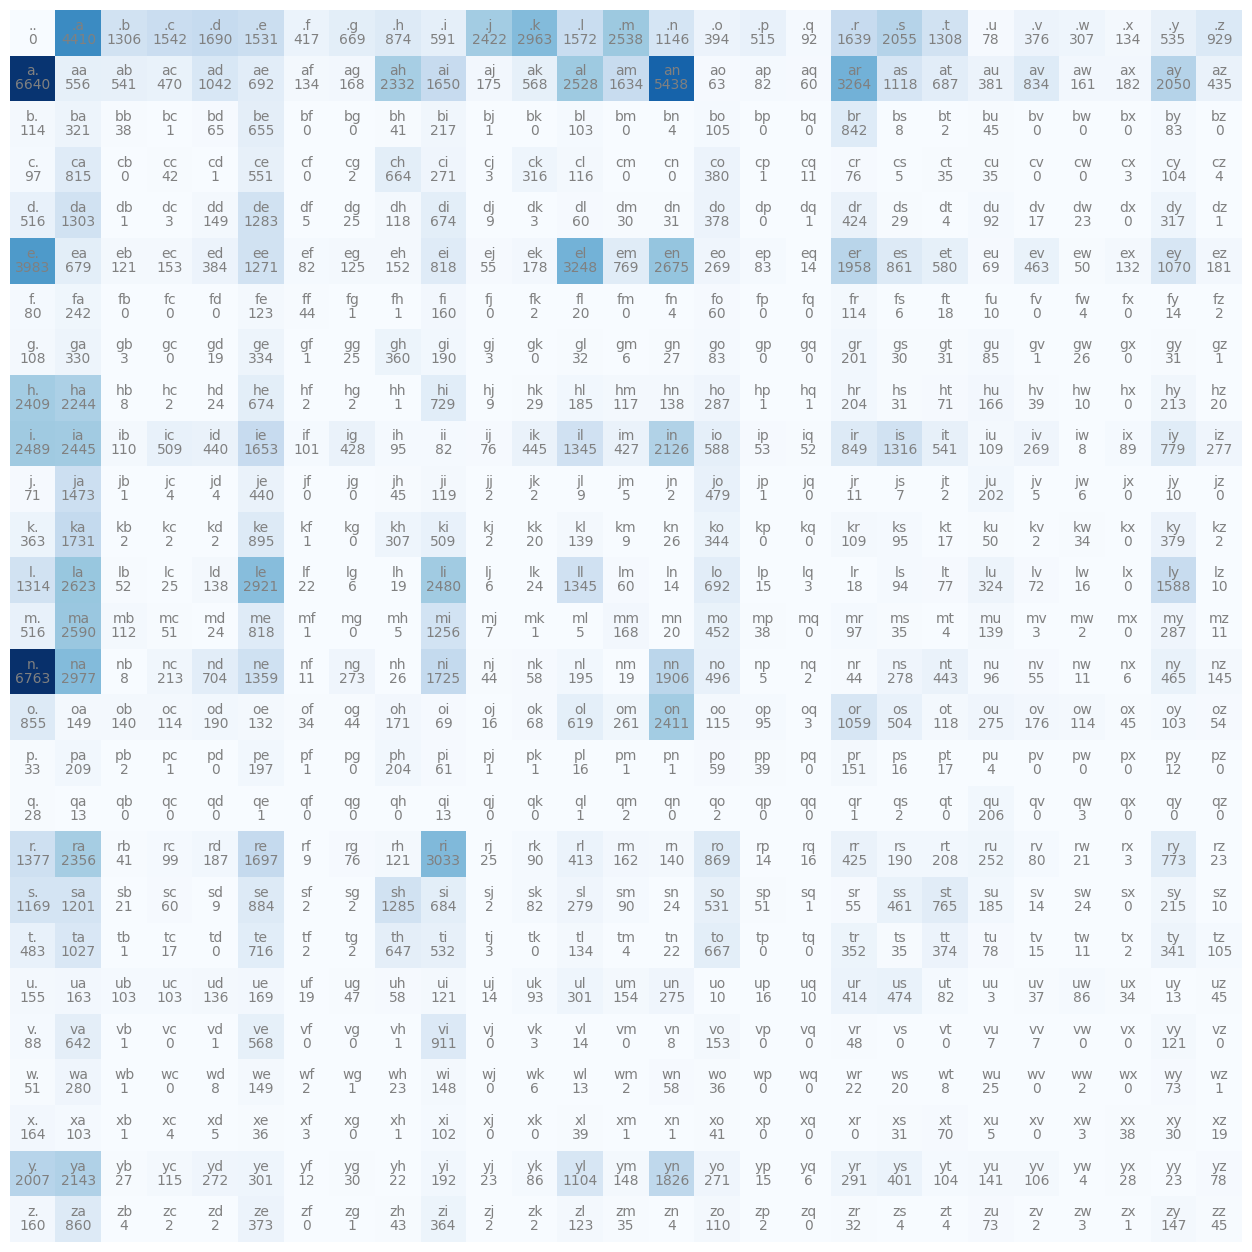

In [5]:
# Plotting frequencies of bigrams
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')  # bigram
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")  # frequency

plt.axis('off')

In [6]:
P = (N + 1).float()
P /= P.sum(1, keepdim=True)

In [7]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, generator = g, replacement=True).item()
        out.append(itos[ix])
        
        if ix==0:
            break
    
    print(''.join(out))

junide.
janasah.
p.
cony.
a.


### Evaluating the Model

We evaluate the model using the negative log likelihood.

We can evaluate the model by going through each bigram in the dataset and calculating the log likelihood of the bigram under the model.

In [8]:
log_likelihood = 0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        log_likelihood += P[ix1, ix2].log()
        n += 1

print(log_likelihood)
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}') # average negative log likelihood

tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


Optimization: Note that the above implementation is not optimized, as we will iterate through the same bigrams multiple times. For example, instead of iterating through a bigram 10 times, we can instead calculate it once and multiply it by 10.

Thus, for each bigram, we can find its log likelihood and multiply it by the number of times it appears in the frequency array N.

This can be optimized using element-wise multiplication, as N[i, j] contains the number of times the bigram (i, j) appears in the dataset, and P[i, j] contains the probability of the bigram (i, j) under the model.

In [9]:
log_likelihood = (N * P.log()).sum()

nll = -log_likelihood
avg = nll / N.sum()
print(avg.item()) # average negative log likelihood

2.4545767307281494


Pros: 
  - Faster vectorized implementation
 
Cons:
  - Requires more memory
  - GUESS, no clue if this is true: Since we use the looping approach for other models, it might be preferred to stick with the looping approach for consistency (as intuitively there may be errors in the looped approach, and we would want to keep these errors so that we can compare the models). 

## Neural Net Approach

The following implementation is implemented with a "Neural Net" approach, which is actually just a linear model.

Each weight in the matrix W represents the log counts of each bigram. 

In [10]:
# create the training set of bigrams
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [11]:
num = xs.nelement()
print(f"There are {num} examples.")

There are 228146 examples.


In [12]:
# initialize the "network"
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True) 
W.shape

torch.Size([27, 27])

In [13]:
# Experiment: Setting W to be the optimal weights

# W = ((N+1) / (N+1).sum(1, keepdim=True)).log()
# W.requires_grad = True

In [14]:
W

tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9643e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01,
         -4.7125e-01,  7.8682e-01, -3.2843e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4039e-01,
          9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0730e-02,
          2.4968e+00,  2.4448e+00],
        [-6.7006e-01, -1.2199e+00,  3.0314e-01, -1.0725e+00,  7.2762e-01,
          5.1114e-02,  1.3095e+00, -8.0220e-01, -8.5042e-01, -1.8068e+00,
          1.2523e+00, -1.2256e+00,  1.2165e+00, -9.6478e-01, -2.3211e-01,
         -3.4762e-01,  3.3244e-01, -1.3263e+00,  1.1224e+00,  5.9641e-01,
          4.5846e-01,  5.4011e-02, -1.7400e+00,  1.1560e-01,  8.0319e-01,
          5.4108e-01, -1.1646e+00],
        [ 1.4756e-01, -1.0006e+00,  3.8012e-01,  4.7328e-01, -9.1027e-01,
         -7.8305e-01,  1.3506e-01, -2.1161e-01, -1.0406e+00, -1.5367e+00,
          9.3743e-01, -8.8303e-01,  1.74

In [15]:
regularization = 0

for k in range(100):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W # prediction
    
    # softmax
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdim=True)
    
    loss = -probs[torch.arange(num), ys].log().mean() + regularization * (W**2).mean()
    
    print(loss.item())

    # backward pass
    
    W.grad = None
    loss.backward()
    
    # update
    W.data -= 50 * W.grad


3.758953809738159
3.371100902557373
3.154043197631836
3.020373821258545
2.927711248397827
2.8604023456573486
2.8097293376922607
2.7701022624969482
2.7380728721618652
2.711496353149414
2.6890029907226562
2.6696884632110596
2.6529300212860107
2.638277769088745
2.6253879070281982
2.6139907836914062
2.60386323928833
2.5948216915130615
2.5867116451263428
2.579403877258301
2.572789192199707
2.5667762756347656
2.5612878799438477
2.5562589168548584
2.551633596420288
2.547366142272949
2.543415069580078
2.539748430252075
2.5363364219665527
2.5331544876098633
2.5301806926727295
2.5273969173431396
2.5247862339019775
2.522334575653076
2.520029067993164
2.517857789993286
2.515810966491699
2.513878107070923
2.512052059173584
2.510324001312256
2.5086867809295654
2.5071346759796143
2.5056610107421875
2.504261016845703
2.502929210662842
2.5016608238220215
2.5004520416259766
2.4992988109588623
2.498197317123413
2.497144937515259
2.496137857437134
2.495173692703247
2.4942493438720703
2.493363380432129
2.4

### Sampling the Model

In [16]:
# Sample from the model

g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        
        logits = xenc @ W
        
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        
        ix = torch.multinomial(p, num_samples=1, generator=g).item()
        out.append(itos[ix])
        
        if ix==0:
            break
            
    print(''.join(out))

junide.
janasah.
p.
cfay.
a.


We can compare the learned weights with the frequency array N.

What we do is apply a softmax to the weights (to get the probability distribution), and then multiply it by the total frequencies to get the expected frequencies.

(-0.5, 26.5, 26.5, -0.5)

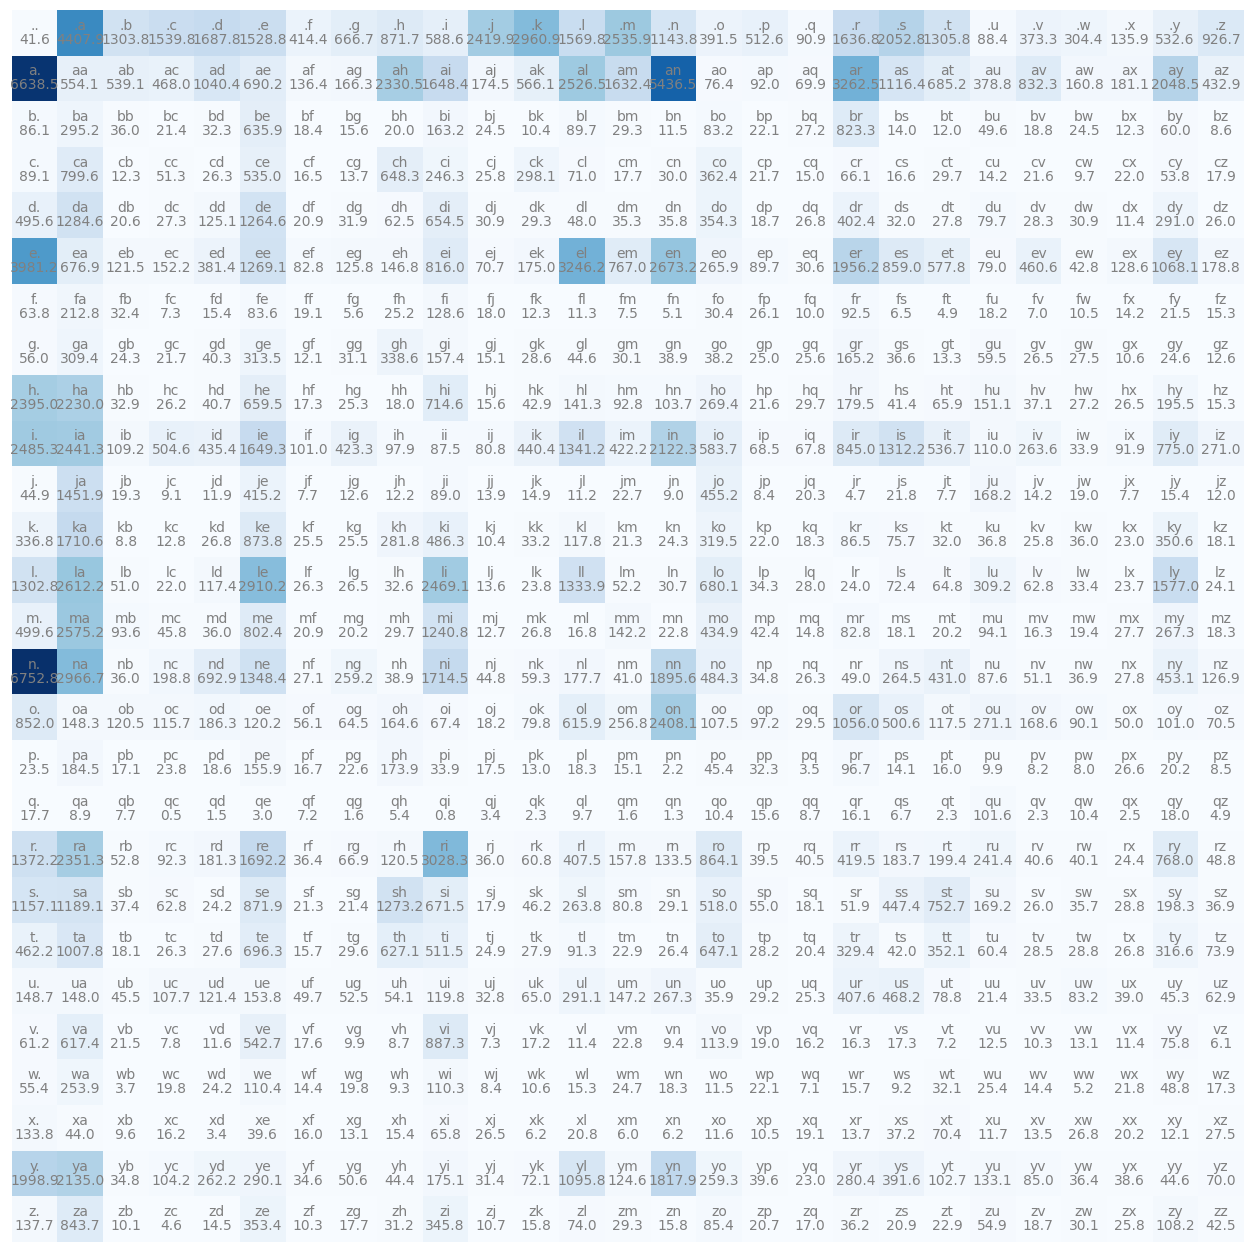

In [17]:
# Plotting frequencies of bigrams
plt.figure(figsize=(16, 16))

weights = (W.exp() / W.exp().sum(1, keepdim=True) * N.sum(1, keepdim=True)).detach().numpy()
plt.imshow(weights, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')  # bigram
        
        text = f'{weights[i, j]:.1f}' # round to 1 decimal
        plt.text(j, i, text, ha="center", va="top", color="gray")  # frequency

plt.axis('off')

Putting them beside each other for comparison lets us see how similar the learned weights are to the frequency array N.

(-0.5, 26.5, 26.5, -0.5)

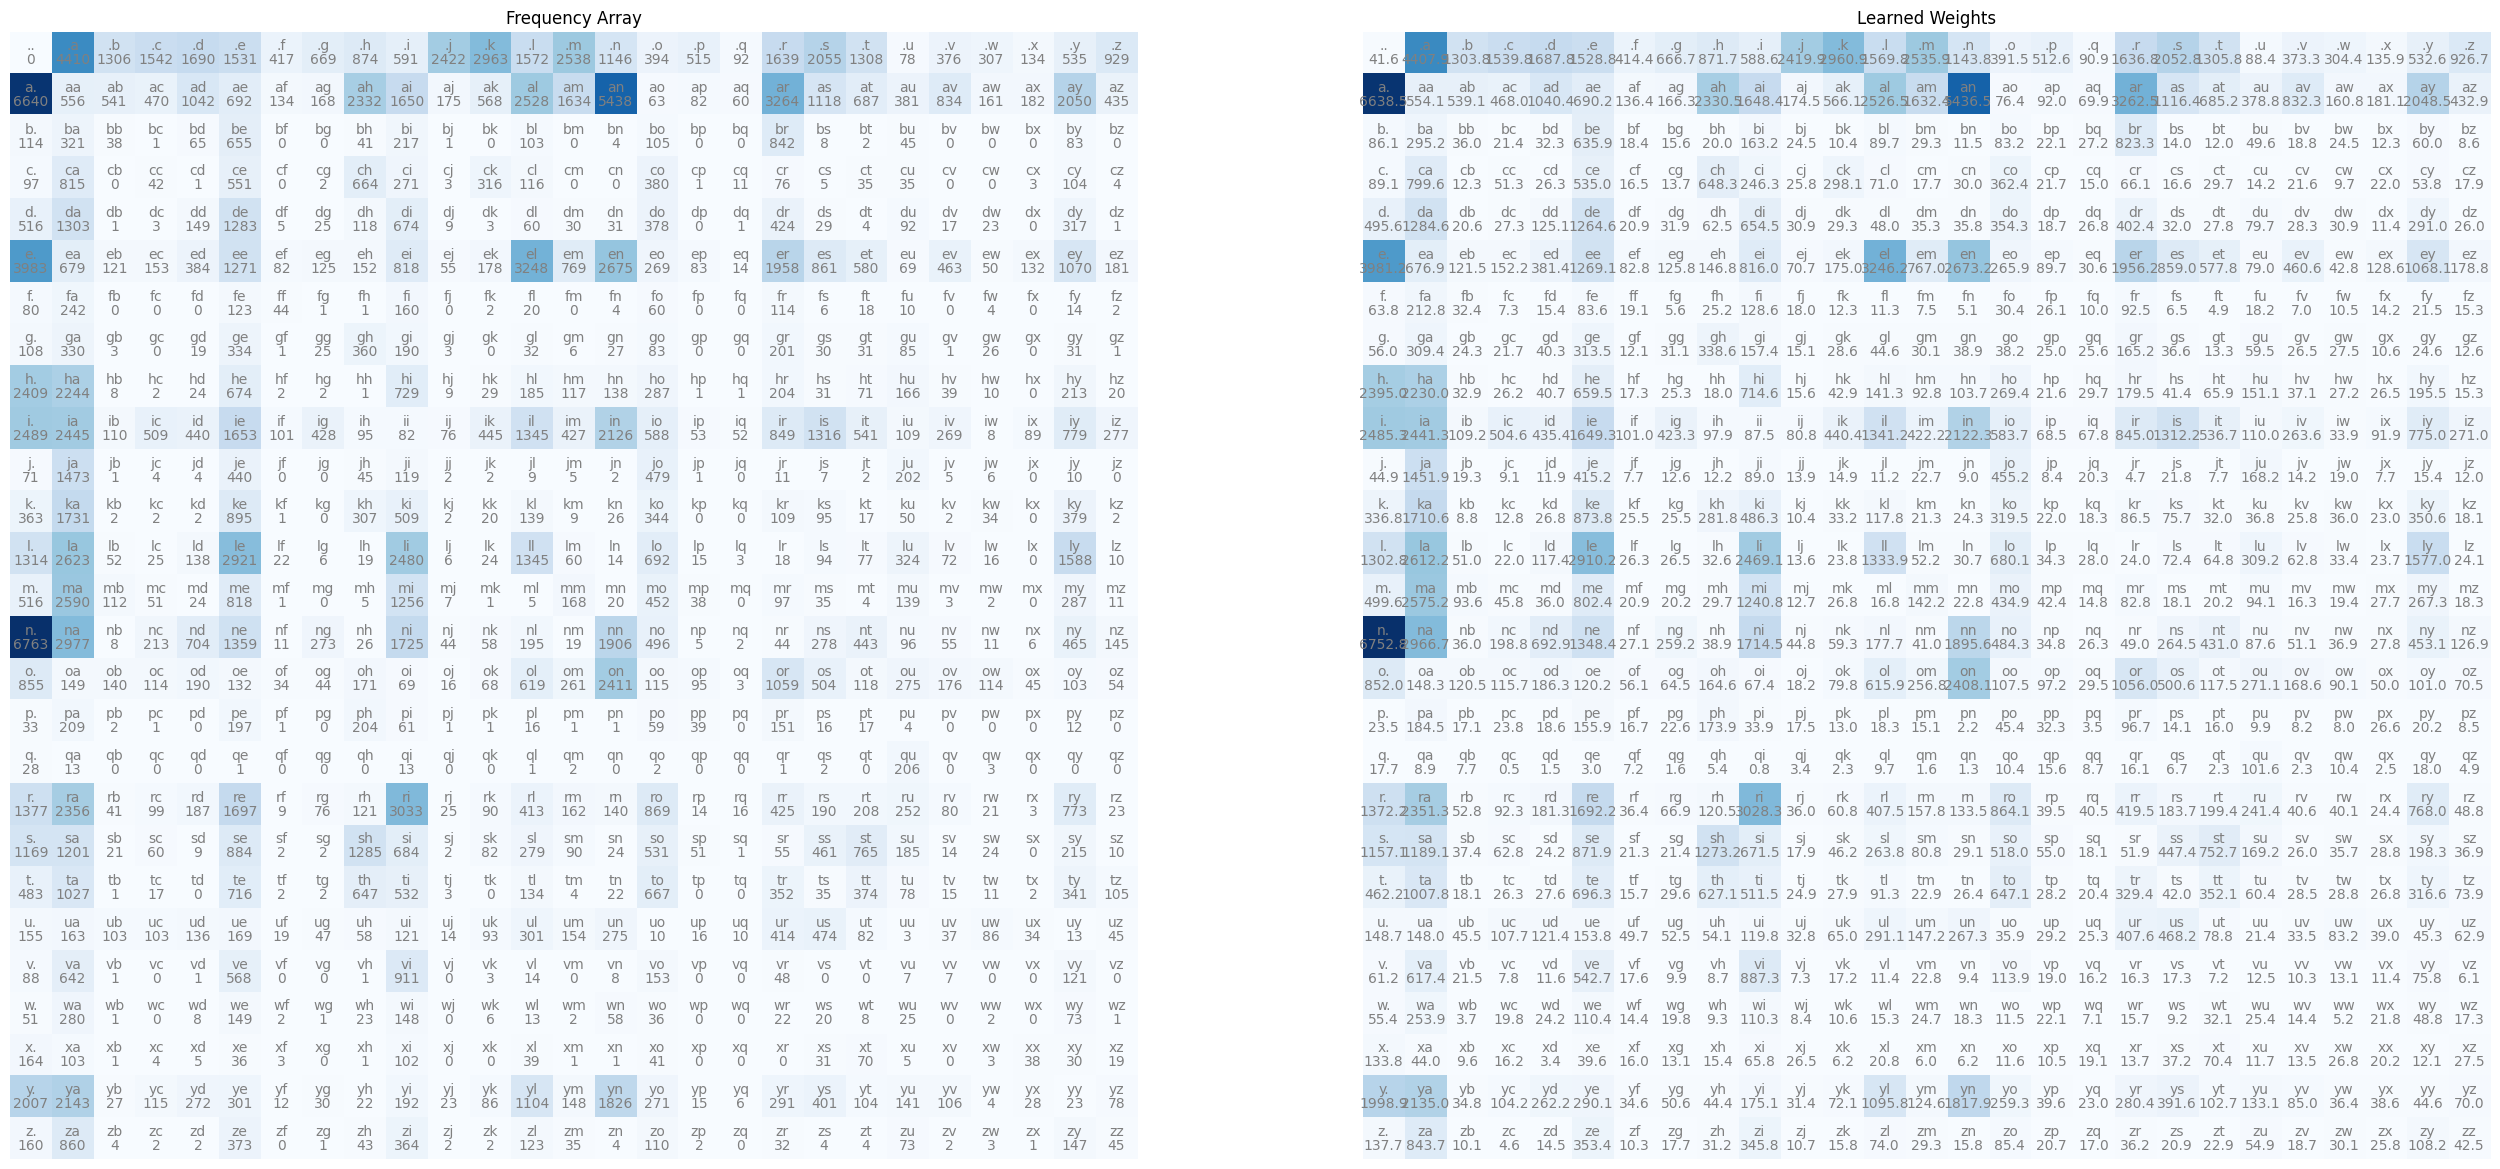

In [18]:
plt.figure(figsize=(32, 17))

# Frequency array N

plt.subplot(1, 2, 1) 
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')  # bigram
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")  # frequency

plt.title('Frequency Array')

plt.axis('off')

# Learned weights

plt.subplot(1, 2, 2)
plt.imshow(weights, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')  # bigram
        plt.text(j, i, f'{weights[i, j]:.1f}', ha="center", va="top", color="gray")  # frequency

plt.title('Learned Weights')

plt.axis('off')

# E01: Trigram Model

The Trigram model takes the previous two characters to predict the next character.

## Counts Approach

We create a frequency array $N$, where $N[i, j, k]$ contains the number of times the trigram $(i, j, k)$ appears in the dataset.

We normalize each row in dim 2 to create a distribution $P[i, j]$, which represents the distribution of characters that follow after $(i ,j)$. Then to predict the next character after $(i, j)$, we sample from this distribution. 

In [19]:
N3 = torch.zeros((27, 27, 27), dtype=torch.int32)

for w in words:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        N3[ix1][ix2][ix3] += 1

# it would be cool if we could make a interactive graph with a slider on ix1 which shows the frequencies of [ix2, ix3] like above

print(N3.sum().item()) # number of examples

228146


In [20]:
P3 = (N3 + 1).float()
P3 /= P3.sum(2, keepdim=True)

### Evaluating the Model

In [21]:
# element approach

log_likelihood = (N3 * P3.log()).sum()
nll = -log_likelihood

average_nll = nll/N3.sum()
average_nll.item()

2.212582588195801

In [22]:
# loop approach

log_likelihood = 0
n = 0

for w in words:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        n += 1
        log_likelihood += P3[ix1, ix2, ix3].log()

nll = -log_likelihood
print(f"{nll=}")
print(f"{nll/n}")

nll=tensor(504653.)
2.2119739055633545


### Sampling the Model

In [23]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix1 = 0
    ix2 = 0
    
    while True:
        p = P3[ix1, ix2]
        ix1 = ix2
        ix2 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix2])
        if ix2==0:
            break
            
    print(''.join(out))
        

junide.
jakasid.
prelay.
adin.
kairritoper.


## Neural Net Approach

In [24]:
# create the training set of trigrams

xs_tri, ys_tri = [], []

for w in words:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        xs_tri.append((ix1, ix2))
        ys_tri.append(ix3)

xs_tri = torch.tensor(xs_tri)
ys_tri = torch.tensor(ys_tri)

print(xs_tri)
ys_tri

tensor([[ 0,  0],
        [ 0,  5],
        [ 5, 13],
        ...,
        [26, 25],
        [25, 26],
        [26, 24]])


tensor([ 5, 13, 13,  ..., 26, 24,  0])

### Attempt 1:

Our input is the one hot encodings of the characters of the pair of characters $(i, j)$ appended together. The result will be a probability distribution of the third character.

Pros:
 - This uses $54\cdot 27$ weights, which is less than the amount of memory used in the counts approach of $27^3$.

Cons:
- As we use fewer weights, it might not represent the dataset well. We can also analyze this under linear tranformations. If we have characters $ab$, this neural net only adds the distributions from $a\_$ and $\_b$ separately, missing the meaning conveyed by their combination.

In [25]:
# initialize the "network"
g = torch.Generator().manual_seed(2147483647)

W3 = torch.randn((54, 27), generator=g, requires_grad = True)

In [26]:
print(xs_tri.shape)
print(F.one_hot(xs_tri, num_classes=27).shape)

F.one_hot(xs_tri, num_classes=27).view(xs_tri.shape[0], -1).shape

torch.Size([228146, 2])
torch.Size([228146, 2, 27])


torch.Size([228146, 54])

In [27]:
xenc = F.one_hot(xs_tri, num_classes=27).view(xs_tri.shape[0], -1).float()

xenc[0]

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [28]:
regularization = 0.01

xenc = F.one_hot(xs_tri, num_classes=27).view(xs_tri.shape[0], -1).float()

# xs_tri is an array of pairs:    [(a, b), (c, d), ...]
# F.one_hot(xs_tri, num_classes=27) is of the form [[(0, 0, 0, 1, 0, ...), (0, 0, 0, 0, 1, ...)], ...] (where each example is 2x27)
# By using view, we flatten each example to an array of 54.

for k in range(1000):
    # forward pass
    logits = xenc @ W3 # prediction

    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)  # softmax
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W ** 2).mean()
    print(loss.item())
    
    # backward pass
    W3.grad = None
    loss.backward()
    
    # update
    W3.data += -10 * W3.grad


4.249421119689941
4.005151271820068
3.8260300159454346
3.6879591941833496
3.575216293334961
3.4789414405822754
3.3957433700561523
3.3236536979675293
3.2609801292419434
3.206210136413574
3.1580448150634766
3.1154134273529053
3.0774478912353516
3.0434505939483643
3.012856960296631
2.9852027893066406
2.960102081298828
2.9372265338897705
2.916294574737549
2.897061586380005
2.8793158531188965
2.8628737926483154
2.8475756645202637
2.833286762237549
2.819889545440674
2.8072845935821533
2.7953882217407227
2.784128427505493
2.7734439373016357
2.763282299041748
2.753598928451538
2.7443535327911377
2.7355141639709473
2.7270495891571045
2.7189340591430664
2.711144208908081
2.7036590576171875
2.696460008621216
2.6895298957824707
2.6828534603118896
2.676417350769043
2.670207977294922
2.6642138957977295
2.6584243774414062
2.652829170227051
2.6474192142486572
2.642186164855957
2.6371209621429443
2.6322176456451416
2.627467393875122
2.6228654384613037
2.6184043884277344
2.6140785217285156
2.60988235473

### Sampling the Model


In [29]:
# sampling from the 'neural network'
g = torch.Generator().manual_seed(2147483647)

for i in range(5):

    out = []
    ix1 = 0
    ix2 = 0
    while True:
        xenc1 = F.one_hot(torch.tensor([ix1]), num_classes=27).float()
        xenc2 = F.one_hot(torch.tensor([ix2]), num_classes=27).float()
        xenc = torch.cat((xenc1, xenc2), 1)
        
        logits = xenc @ W3
        counts = logits.exp()
        p = counts / counts.sum(1, keepdims=True)
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        ix1 = ix2
        ix2 = ix
    
        if ix==0:
            break

    print(''.join(out))

juwide.
janasad.
pariay.
ainn.
koi.


### Attempt 2:

This attempt mimics the counts method. There will be a $27 \cdot 27 = 729$ input weights representing all the different possible inputs. The output will be a probability distribution of the third character.

In [30]:
g = torch.Generator().manual_seed(2147483647)
W3 = torch.randn((27*27, 27), generator=g, requires_grad=True)

In [31]:
xs_tri

tensor([[ 0,  0],
        [ 0,  5],
        [ 5, 13],
        ...,
        [26, 25],
        [25, 26],
        [26, 24]])

In [32]:
regularization = 0.01

xenc = F.one_hot(xs_tri[:, 0] * 27 + xs_tri[:, 1], num_classes=27*27).float()

for k in range(1000):
    # forward pass
    logits = xenc @ W3 # prediction
    
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    
    loss = -probs[torch.arange(num), ys_tri].log().mean() + regularization * (W3**2).mean()
    
    print(loss.item())

    # backward pass
    
    W3.grad = None
    loss.backward()
    
    # update
    W3.data -= 10 * W3.grad    
    

3.8028228282928467
3.7669339179992676
3.735516309738159
3.7074239253997803
3.6819632053375244
3.6586668491363525
3.637197971343994
3.6172990798950195
3.5987658500671387
3.5814268589019775
3.565136194229126
3.5497658252716064
3.5352020263671875
3.521345376968384
3.508107900619507
3.495415449142456
3.483203649520874
3.471418619155884
3.4600155353546143
3.4489569664001465
3.4382131099700928
3.4277565479278564
3.4175662994384766
3.407623291015625
3.3979122638702393
3.3884193897247314
3.3791327476501465
3.3700413703918457
3.3611366748809814
3.3524093627929688
3.3438527584075928
3.3354597091674805
3.327223777770996
3.3191401958465576
3.3112025260925293
3.3034067153930664
3.295747995376587
3.2882227897644043
3.2808260917663574
3.273555278778076
3.266406297683716
3.25937557220459
3.2524607181549072
3.2456579208374023
3.238964319229126
3.2323780059814453
3.2258946895599365
3.219512701034546
3.2132298946380615
3.2070424556732178
3.200948715209961
3.194946527481079
3.189033269882202
3.18320679664

Observations:

The loss starts off larger for larger networks, but then converges to a lower value.

### Sampling the Model


In [33]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix1 = 0
    ix2 = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix1 * 27 + ix2]), num_classes=27*27).float()
        
        logits = xenc @ W3
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
    
        ix2 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        ix1 = ix2
        
        out.append(itos[ix2])
        
        if ix2 == 0:
            break
    
    print(''.join(out))


juwjdv.
jpnaqadhu.
cfaywadvow.
jiiritohoraratezzusane.
auydbilenani.


# E02: Train Dev Test Split

We will now implement the train dev test split for the bigram and trigram models.

In [34]:
# train dev test split

# shuffle words
g = torch.Generator().manual_seed(2147483647)
words = [words[i] for i in torch.randperm(len(words), generator=g)]

train_len = int(0.8 * len(words))
dev_len = int(0.1 * len(words))
test_len = len(words) - train_len - dev_len

train = words[:train_len]
dev = words[train_len:train_len + dev_len]
test = words[train_len + dev_len:]


## Bigram Model

In [35]:
# bigram model
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)


In [36]:
# training the bigram model
xs, ys, xs_dev, ys_dev, xs_test, ys_test = [], [], [], [], [], []

for w in train:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
        
for w in dev:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs_dev.append(ix1)
        ys_dev.append(ix2)
        
for w in test:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs_test.append(ix1)
        ys_test.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
xs_dev = torch.tensor(xs_dev)
ys_dev = torch.tensor(ys_dev)
xs_test = torch.tensor(xs_test)
ys_test = torch.tensor(ys_test)
num = xs.nelement()

In [37]:
ys.shape

torch.Size([182583])

In [38]:
for k in range(100):
    # forward pass
    # xenc = F.one_hot(xs, num_classes=27).float()
    logits = W[xs] # prediction
    
    # softmax
    # counts = logits.exp()
    # probs = counts / counts.sum(dim=1, keepdim=True)
    # 
    # loss = -probs[torch.arange(num), ys].log().mean()
    
    loss = F.cross_entropy(logits, ys)
    
    print(loss.item())

    # backward pass
    
    W.grad = None
    loss.backward()
    
    # update
    W.data -= 50 * W.grad

3.7549569606781006
3.3683512210845947
3.1520533561706543
3.018935203552246
2.926731586456299
2.8597757816314697
2.809375524520874
2.76995849609375
2.738085985183716
2.7116241455078125
2.68921160697937
2.6699514389038086
2.653226613998413
2.6385931968688965
2.625711441040039
2.614314556121826
2.6041834354400635
2.5951340198516846
2.587013006210327
2.5796926021575928
2.573063611984253
2.5670363903045654
2.5615339279174805
2.5564916133880615
2.5518548488616943
2.547576904296875
2.5436179637908936
2.5399444103240967
2.536527395248413
2.5333409309387207
2.530365228652954
2.5275793075561523
2.524967908859253
2.5225160121917725
2.5202107429504395
2.518040418624878
2.515994071960449
2.5140628814697266
2.512238025665283
2.510511636734009
2.508876323699951
2.507326126098633
2.505854845046997
2.5044567584991455
2.503126621246338
2.5018608570098877
2.5006539821624756
2.4995028972625732
2.498403787612915
2.4973533153533936
2.4963483810424805
2.4953861236572266
2.494464159011841
2.4935801029205322
2

In [39]:
# Evaluating on dev set

# n = xs_dev.nelement()
# xenc = F.one_hot(xs_dev, num_classes=27).float()
# logits = xenc @ W
logits = W[xs_dev]
# counts = logits.exp()
# probs = counts / counts.sum(dim=1, keepdim=True)
# log_likelihood = probs[torch.arange(n), ys_dev].log().sum()
#     
# nll = -log_likelihood.item()
nloss = F.cross_entropy(logits, ys_dev)
print("Dev Set:")
# print(f'{nll=}')
# print(f'{nll/n}') # average negative log likelihood
print(nloss.item())

# Evaluating on test set

# n = xs_test.nelement()
# xenc = F.one_hot(xs_test, num_classes=27).float()
# logits = xenc @ W
logits = W[xs_test]
# counts = logits.exp()
# probs = counts / counts.sum(dim=1, keepdim=True)
# log_likelihood = probs[torch.arange(n), ys_test].log().sum()
# 
# nll = -log_likelihood.item()
nloss = F.cross_entropy(logits, ys_test)

print("Test Set:")
# print(f'{nll=}')
# print(f'{nll/n}') # average negative log likelihood
print(nloss.item())


Dev Set:
2.4725682735443115
Test Set:
2.4724316596984863


## Trigram Model

In [40]:
g = torch.Generator().manual_seed(2147483647)
W3 = torch.randn((27 * 27, 27), generator=g, requires_grad=True)

In [41]:
xs, ys, xs_dev, ys_dev, xs_test, ys_test = [], [], [], [], [], []

for w in train:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        xs.append((ix1, ix2))
        ys.append(ix3)
        
for w in dev:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        xs_dev.append((ix1, ix2))
        ys_dev.append(ix3)
        
for w in test:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        xs_test.append((ix1, ix2))
        ys_test.append(ix3)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)
xs_dev = torch.tensor(xs_dev)
ys_dev = torch.tensor(ys_dev)
xs_test = torch.tensor(xs_test)
ys_test = torch.tensor(ys_test)
num = ys.nelement()

In [42]:
regularization = 0.001

#xenc = F.one_hot(xs[:, 0] * 27 + xs[:, 1], num_classes=27*27).float()

def learning_rate(k):
    if k > 8000:
        return 30
    if k > 13000:
        return 10
    if k > 17000:
        return 5
    return 50

num_range = torch.arange(num)

for k in range(0, 2000):
    # forward pass
    #logits = xenc @ W3 # prediction
    
    logits = W3[xs[:, 0] * 27 + xs[:, 1]]

    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)

    # loss = -probs[num_range, ys].log().mean() + regularization * (W3**2).mean()
        
    loss = F.cross_entropy(logits, ys) + regularization * (W3**2).mean()
    
    print(loss.item())
        
    # backward pass

    W3.grad = None
    loss.backward()

    # update
    W3.data -= learning_rate(k) * W3.grad

3.7936489582061768
3.6398022174835205
3.548018455505371
3.480302572250366
3.4244039058685303
3.3752918243408203
3.331146001815796
3.2909839153289795
3.254194736480713
3.220346212387085
3.1890881061553955
3.1601157188415527
3.1331565380096436
3.107973575592041
3.084362268447876
3.0621497631073
3.041191577911377
3.0213654041290283
3.0025713443756104
2.9847214221954346
2.9677422046661377
2.9515693187713623
2.936145782470703
2.9214210510253906
2.9073503017425537
2.8938918113708496
2.881009817123413
2.868668556213379
2.8568365573883057
2.845484733581543
2.834585428237915
2.8241124153137207
2.814042806625366
2.8043529987335205
2.7950222492218018
2.786029815673828
2.7773571014404297
2.768986463546753
2.76090145111084
2.7530856132507324
2.745525360107422
2.738205671310425
2.7311153411865234
2.724240779876709
2.717571496963501
2.711097240447998
2.704807996749878
2.6986947059631348
2.6927490234375
2.686962366104126
2.681328535079956
2.675839424133301
2.67048978805542
2.6652729511260986
2.6601831

In [43]:
# Evaluating on dev set
# n = ys_dev.nelement()
# xenc = F.one_hot(xs_dev[:, 0] * 27 + xs_dev[:, 1], num_classes=27*27).float()
#logits = xenc @ W3
logits = W3[xs_dev[:, 0] * 27 + xs_dev[:, 1]]
# counts = logits.exp()
# probs = counts / counts.sum(dim=1, keepdim=True)
# log_likelihood = probs[torch.arange(n), ys_dev].log().sum()

nll = F.cross_entropy(logits, ys_dev).item()

# nll = -log_likelihood.item()
print("Dev Set:")
# print(f'{nll=}')
print(f'{nll}') # average negative log likelihood

# Evaluating on test set
# log_likelihood = 0
# n = ys_test.nelement()

logits = W3[xs_test[:, 0] * 27 + xs_test[:, 1]]
# counts = logits.exp()
# probs = counts / counts.sum(dim=1, keepdim=True)
# log_likelihood = probs[torch.arange(n), ys_test].log().sum()
# 
# nll = -log_likelihood.item()
nll = F.cross_entropy(logits, ys_test).item()
print("Test Set:")
# print(f'{nll=}')
print(f'{nll}') # average negative log likelihood

Dev Set:
2.244127035140991
Test Set:
2.235062837600708


Notes:

It seems that reducing the loss on the train set does reduce the loss on the dev and test set.

Regularization: 0.001
 - Train: 2.189349889755249
- Dev:    2.2309582144666695
- Test:   2.222070124584536

Regularization: 0.01
 - Train: 2.2275071144104004
- Dev: 2.2454359675838216
- Test: 2.2365391028164088

Regularization: 0.1
- Train: 2.2936160564422607
- Dev:   2.2548292450544123
- Test:  2.246779470611388

Regularization: 0.2
- Train: 2.3066177368164062
- Dev:   2.2611330792615765
- Test: 2.253223604368932

Regularization: 0.50
- Train: 2.4493050575256348
- Dev: 2.334816929274794
- Test: 2.3282628616176857

In our case, it seems like the lower the regularization, the better the model performs.